In [1]:
# ===============================
# IPL Statistical Analysis
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\mywork\Ipl_Analysis\/data/ipl_cleaned.csv", low_memory=False)

In [5]:
match_df = df.groupby("match_id").agg({
    "ipl_season": "first",
    "toss_winner": "first",
    "toss_decision": "first",
    "match_won_by": "first",
    "win_type": "first",
    "win_margin": "first",
    "venue": "first"
}).reset_index()

match_df.shape

(1169, 8)

In [7]:
first_innings = df[df["innings"] == 1].groupby("match_id")["team_runs"].max()

match_df = match_df.merge(
    first_innings.rename("first_innings_score"),
    on="match_id",
    how="left"
)

In [9]:
first_wickets = df[df["innings"] == 1].groupby("match_id")["team_wicket"].max()

match_df = match_df.merge(
    first_wickets.rename("first_innings_wickets"),
    on="match_id",
    how="left"
)

In [11]:
match_df.head()

,match_id,ipl_season,toss_winner,toss_decision,match_won_by,win_type,win_margin,venue,first_innings_score,first_innings_wickets
0,335982,2008,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,"M Chinnaswamy Stadium, Bengaluru",222,3
1,335983,2008,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,"Punjab Cricket Association IS Bindra Stadium, ...",240,5
2,335984,2008,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,"Arun Jaitley Stadium, Delhi",129,8
3,335985,2008,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,"Wankhede Stadium, Mumbai",165,6
4,335986,2008,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,"Eden Gardens, Kolkata",110,10


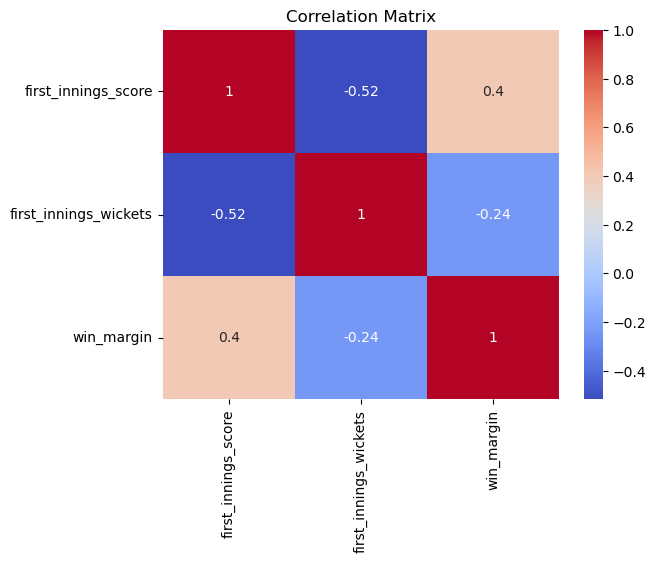

,first_innings_score,first_innings_wickets,win_margin
first_innings_score,1.000000,-0.517112,0.404888
first_innings_wickets,-0.517112,1.000000,-0.241057
win_margin,0.404888,-0.241057,1.000000


In [13]:
numeric_cols = [
    "first_innings_score",
    "first_innings_wickets",
    "win_margin"
]

corr = match_df[numeric_cols].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

corr

In [17]:
import scipy.stats as stats

contingency = pd.crosstab(
    match_df["toss_decision"],
    match_df["win_type"]
)

contingency

win_type,runs,wickets
toss_decision,,
bat,186,210
field,345,405


In [19]:
chi2, p, dof, expected = stats.chi2_contingency(contingency)

chi2, p

(0.06288596367422312, 0.801991365508992)

In [21]:
chasing_wins = (match_df["win_type"] == "wickets").sum()
defending_wins = (match_df["win_type"] == "runs").sum()

total_matches = match_df.shape[0]

chasing_wins, defending_wins, total_matches

(615, 531, 1169)

In [23]:
chasing_rate = chasing_wins / (chasing_wins + defending_wins)
chasing_rate

0.5366492146596858

In [25]:
from statsmodels.stats.proportion import proportions_ztest

count = chasing_wins
nobs = chasing_wins + defending_wins

z_stat, p_value = proportions_ztest(count, nobs, value=0.5)

z_stat, p_value

(2.488036692099196, 0.012845047985551741)

In [27]:
venue_counts = match_df["venue"].value_counts()

major_venues = venue_counts[venue_counts >= 20].index

filtered_df = match_df[match_df["venue"].isin(major_venues)]

len(major_venues)

15

In [29]:
from scipy import stats

groups = [
    filtered_df[filtered_df["venue"] == venue]["first_innings_score"]
    for venue in major_venues
]

In [31]:
f_stat, p_value = stats.f_oneway(*groups)

f_stat, p_value

(2.168512189378534, 0.007482380785259877)

In [33]:
season_rr = df.groupby("ipl_season")["runs_total"].sum() / \
            df.groupby("ipl_season")["valid_ball"].sum() * 6

season_rr = season_rr.reset_index()
season_rr.columns = ["season", "run_rate"]

season_rr.head()

,season,run_rate
0,2008,8.310579
1,2009,7.492784
2,2010,8.128713
3,2011,7.727489
4,2012,7.828801


In [35]:
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(
    season_rr["season"],
    season_rr["run_rate"]
)

slope, p_value

(0.08456396223391167, 0.0001245829243861035)